In [5]:
# ============================================================
# EDA: Global Maternal Mortality (World Bank / WHO, 2000-2023)
# Course: DLBDSEDAV01 – Exploratory Data Analysis and Visualization
# ============================================================
# Data files required in the same folder as this script:
#   API_SH.STA.MMRT_DS2_en_csv_v2_1064.csv
#   API_NY.GDP.PCAP.CD_DS2_en_csv_v2_245.csv
#   API_SH.STA.BRTC.ZS_DS2_en_csv_v2_5636.csv
#   API_SP.ADO.TFRT_DS2_en_csv_v2_6547.csv
#   API_SH_XPD_CHEX_PC_CD_DS2_en_csv_v2_645.csv
#   API_SH_XPD_OOPC_CH_ZS_DS2_en_csv_v2_2201.csv
#   API_SP_POP_TOTL_DS2_en_csv_v2_58.csv
#   Metadata_Country_API_SH.STA.MMRT_DS2_en_csv_v2_1064.csv
#   naturalearth_lowres.shp  (bundled with pyogrio / geopandas)
# ============================================================
 
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
 
# Global style
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
})
 
# Consistent colour palette
REGION_COLORS = {
    "Sub-Saharan Africa":          "#E63946",
    "South Asia":                  "#F4A261",
    "East Asia & Pacific":         "#2A9D8F",
    "Middle East & North Africa":  "#E9C46A",
    "Latin America & Caribbean":   "#457B9D",
    "Europe & Central Asia":       "#6A994E",
    "North America":               "#A8DADC",
}
INCOME_COLORS = {
    "Low income":           "#E63946",
    "Lower middle income":  "#F4A261",
    "Upper middle income":  "#457B9D",
    "High income":          "#6A994E",
}
INCOME_ORDER = ["Low income", "Lower middle income", "Upper middle income", "High income"]
USA_COLOR    = "#E63946"
PEER_COLOR   = "#457B9D"
PEER_LIGHT   = "#A8DADC"
 
# Path to naturalearth shapefile
SHAPEFILE_PATH = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
 
# OECD peer list
OECD_PEERS = [
    "United States", "Germany", "France", "United Kingdom", "Canada",
    "Japan", "Australia", "Italy", "Spain", "Sweden", "Norway", "Denmark",
    "Finland", "Netherlands", "Belgium", "Switzerland", "Austria", "Ireland",
    "Korea, Rep.", "Portugal", "New Zealand",
]

In [6]:
# DATA LOADING

 
def load_wb(filepath, col_name, y0=2000, y1=2023):
    df = pd.read_csv(filepath, skiprows=4)
    df = df.dropna(subset=["Country Code"])
    yc = [c for c in df.columns if c.strip().isdigit() and y0 <= int(c) <= y1]
    df = df[["Country Name", "Country Code"] + yc]
    df = df.melt(id_vars=["Country Name", "Country Code"],
                 var_name="Year", value_name=col_name)
    df["Year"] = df["Year"].astype(int)
    return df
 
def load_population(filepath):
    raw = pd.read_csv(filepath, skiprows=4)
    raw = raw.dropna(subset=["Country Code"])
    yc  = sorted([c for c in raw.columns if c.strip().isdigit() and int(c) >= 2000])
    df  = raw[["Country Code"] + yc].copy()
    def latest(row):
        for y in reversed(yc):
            if pd.notna(row[y]) and row[y] > 0: return row[y]
        return np.nan
    df["Population"] = df.apply(latest, axis=1)
    return df[["Country Code", "Population"]].dropna()
 
mmr   = load_wb("API_SH.STA.MMRT_DS2_en_csv_v2_1064.csv",      "MMR")
gdp   = load_wb("API_NY.GDP.PCAP.CD_DS2_en_csv_v2_245.csv",     "GDP_per_capita")
birth = load_wb("API_SH.STA.BRTC.ZS_DS2_en_csv_v2_5636.csv",   "Skilled_birth_pct")
adol  = load_wb("API_SP.ADO.TFRT_DS2_en_csv_v2_6547.csv",      "Adolescent_fertility")
hexp  = load_wb("API_SH.XPD.CHEX.PC.CD_DS2_en_csv_v2_645.csv", "Health_exp_pc")
oop   = load_wb("API_SH.XPD.OOPC.CH.ZS_DS2_en_csv_v2_2201.csv","OOP_pct")
pop   = load_population("API_SP.POP.TOTL_DS2_en_csv_v2_58.csv")
 
meta = pd.read_csv("Metadata_Country_API_SH.STA.MMRT_DS2_en_csv_v2_1064.csv")
meta = meta[["Country Code", "Region", "IncomeGroup"]].dropna(subset=["Region"])
 
df = mmr.copy()
for other in [gdp, birth, adol, hexp, oop]:
    df = df.merge(other, on=["Country Name", "Country Code", "Year"], how="left")
df = df.merge(meta, on="Country Code", how="left")
df = df.merge(pop,  on="Country Code", how="left")
 
# Keep real countries only (have Region assigned)
df = df[df["Region"].notna()].copy()
 
# Population tiers — computed BEFORE micro exclusion so Step 6 can show all tiers
POP_BINS   = [0, 1e6, 10e6, 50e6, float("inf")]
POP_LABELS = ["Micro (<1M)", "Small (1-10M)", "Medium (10-50M)",
              "Large (50M<)"]
df["Pop_tier"] = pd.cut(df["Population"], bins=POP_BINS, labels=POP_LABELS)

latest_full = df.sort_values("Year").groupby("Country Name").last().reset_index()

NUMERIC_VARS = ["MMR", "GDP_per_capita", "Skilled_birth_pct",
                "Adolescent_fertility", "Health_exp_pc", "OOP_pct"]
VAR_LABELS   = {
    "MMR":                 "MMR",
    "GDP_per_capita":      "GDP/cap",
    "Skilled_birth_pct":   "Skilled\nBirth %",
    "Adolescent_fertility":"Adol.\nFert.",
    "Health_exp_pc":       "Health\nExp/cap",
    "OOP_pct":             "OOP %",
}
 
print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print(f"Full longitudinal dataset: {df['Country Name'].nunique()} countries")

DATA LOADED
Full longitudinal dataset: 217 countries


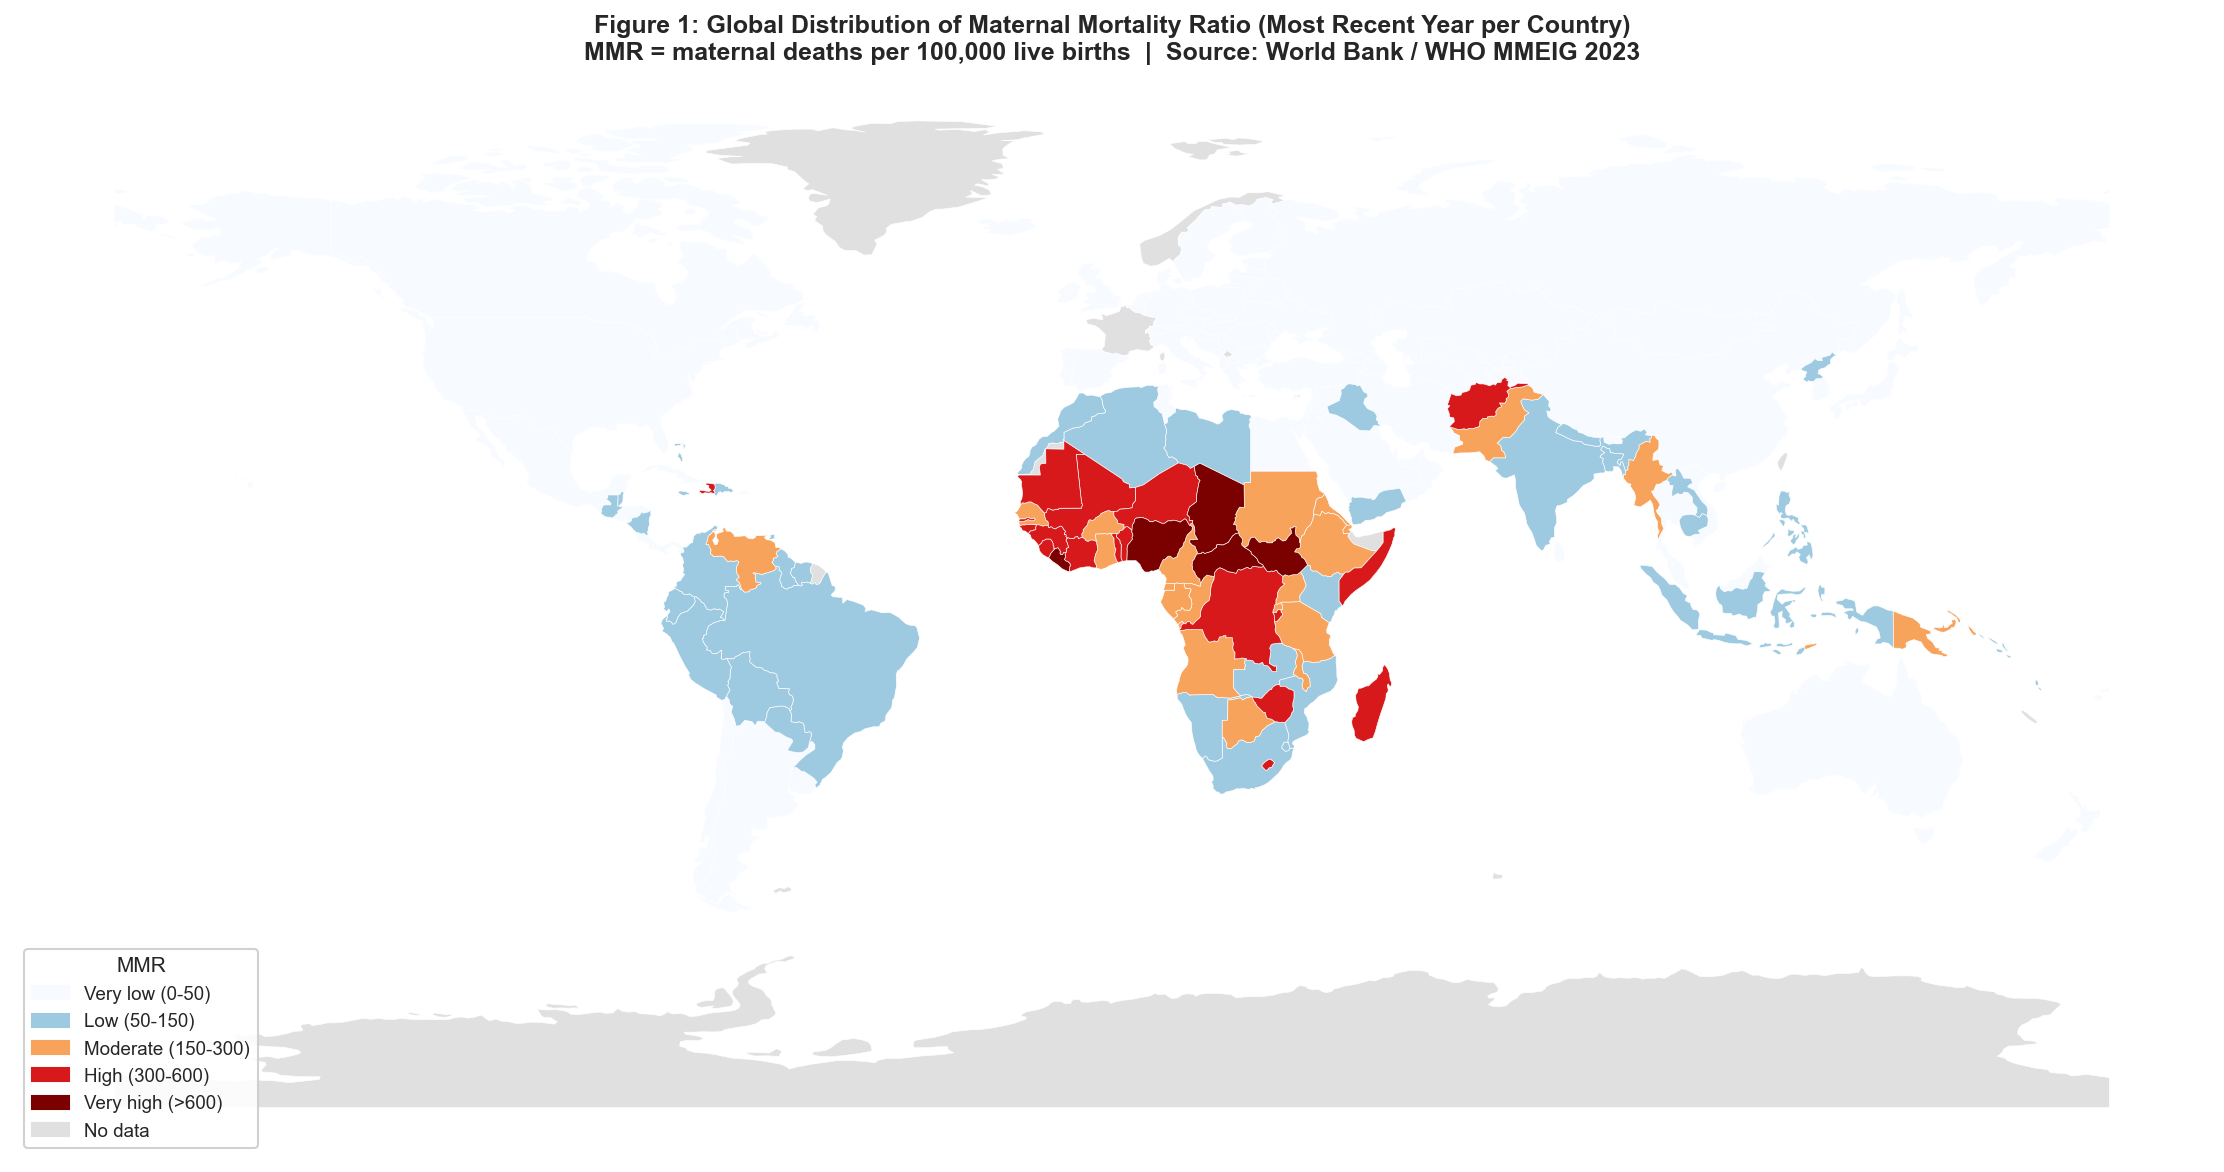

Figure 1 saved


In [7]:
# GLOBAL MAP

world = gpd.read_file(SHAPEFILE_PATH)
map_df = world.merge(
    latest_full[["Country Code", "MMR"]].dropna(subset=["MMR"]),
    left_on="ISO_A3", right_on="Country Code", how="left"
)
bins_map   = [0, 50, 150, 300, 600, 1100]
labels_map = ["Very low (0-50)", "Low (50-150)", "Moderate (150-300)",
               "High (300-600)", "Very high (>600)"]
bin_colors = ["#f7fbff", "#9ecae1", "#f7a35c", "#d7191c", "#7b0000"]
map_df["MMR_cat"] = pd.cut(map_df["MMR"], bins=bins_map,
                            labels=labels_map, right=False)
 
fig, ax = plt.subplots(figsize=(16, 8))
map_df[map_df["MMR"].isna()].plot(ax=ax, color="#e0e0e0",
                                   linewidth=0.3, edgecolor="white")
for cat, color in zip(labels_map, bin_colors):
    map_df[map_df["MMR_cat"] == cat].plot(
        ax=ax, color=color, linewidth=0.3, edgecolor="white", label=cat)
 
ax.set_title(
    "Figure 1: Global Distribution of Maternal Mortality Ratio (Most Recent Year per Country)\n"
    "MMR = maternal deaths per 100,000 live births  |  Source: World Bank / WHO MMEIG 2023",
    fontsize=12, fontweight="bold")
ax.set_axis_off()
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(bin_colors, labels_map)]
patches.append(mpatches.Patch(color="#e0e0e0", label="No data"))
ax.legend(handles=patches, title="MMR", loc="lower left",
          fontsize=9, title_fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig("figure1_choropleth.png")
plt.show()
print("Figure 1 saved")


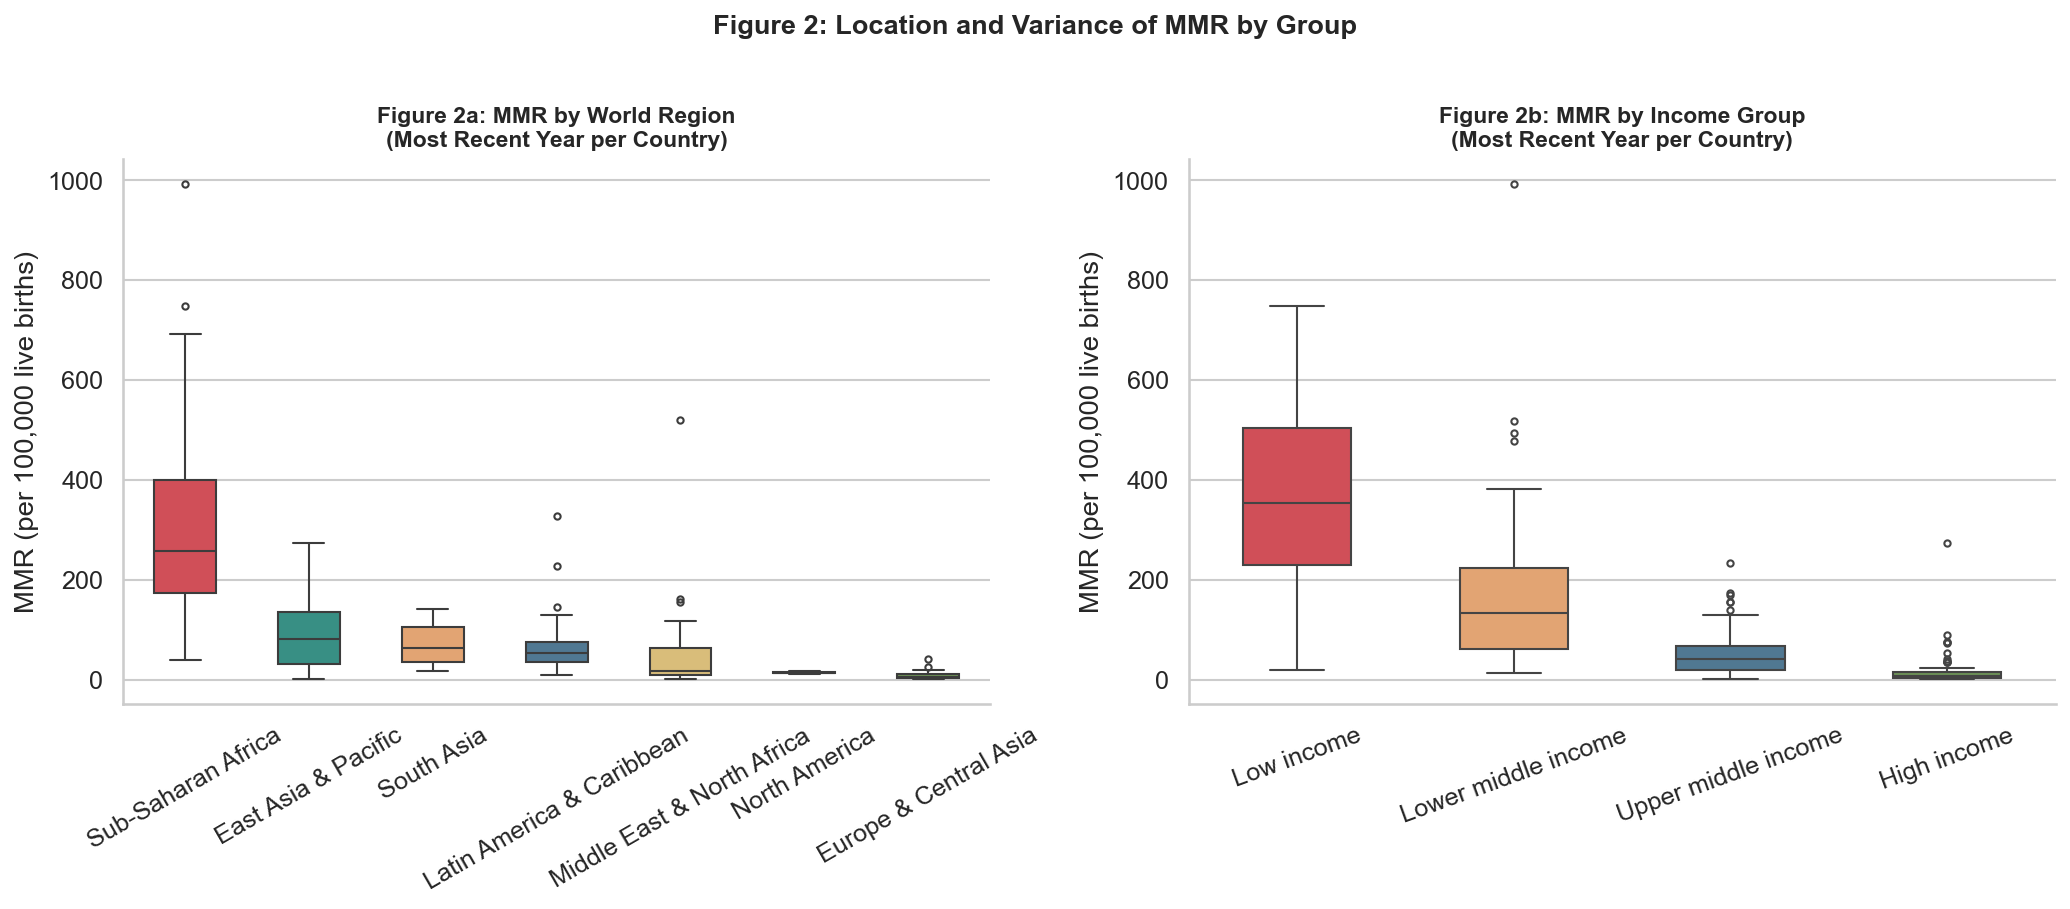

Figure 2 saved


In [8]:
# GROUP COMPARISONS — Box Plots

 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Figure 2a: by Region
lat_reg = latest_full.dropna(subset=["Region", "MMR"])
reg_order = (lat_reg.groupby("Region")["MMR"]
             .median().sort_values(ascending=False).index)
reg_colors = [REGION_COLORS.get(r, "grey") for r in reg_order]
sns.boxplot(data=lat_reg, x="Region", y="MMR", order=reg_order,
            palette=reg_colors, ax=axes[0], width=0.5, fliersize=3)
axes[0].set_title("Figure 2a: MMR by World Region\n(Most Recent Year per Country)",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("MMR (per 100,000 live births)")
axes[0].tick_params(axis="x", rotation=30)
 
# Figure 2b: by Income Group
lat_inc = latest_full.dropna(subset=["IncomeGroup", "MMR"])
inc_colors = [INCOME_COLORS[g] for g in INCOME_ORDER]
sns.boxplot(data=lat_inc, x="IncomeGroup", y="MMR", order=INCOME_ORDER,
            palette=inc_colors, ax=axes[1], width=0.5, fliersize=3)
axes[1].set_title("Figure 2b: MMR by Income Group\n(Most Recent Year per Country)",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("MMR (per 100,000 live births)")
axes[1].tick_params(axis="x", rotation=20)
 
plt.suptitle("Figure 2: Location and Variance of MMR by Group",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figure2_boxplots.png")
plt.show()
print("Figure 2 saved")

In [9]:
# micro-states excluded
df_clean    = df[df["Pop_tier"] != "Micro (<1M)"].copy()
latest      = df_clean.sort_values("Year").groupby("Country Name").last().reset_index()
micro_names = df[df["Pop_tier"] == "Micro (<1M)"]["Country Name"].unique()
print(f"\nMicro-states excluded from Steps 2-7: {len(micro_names)}")
print(f"Countries remaining: {latest['Country Name'].nunique()}")


Micro-states excluded from Steps 2-7: 57
Countries remaining: 160


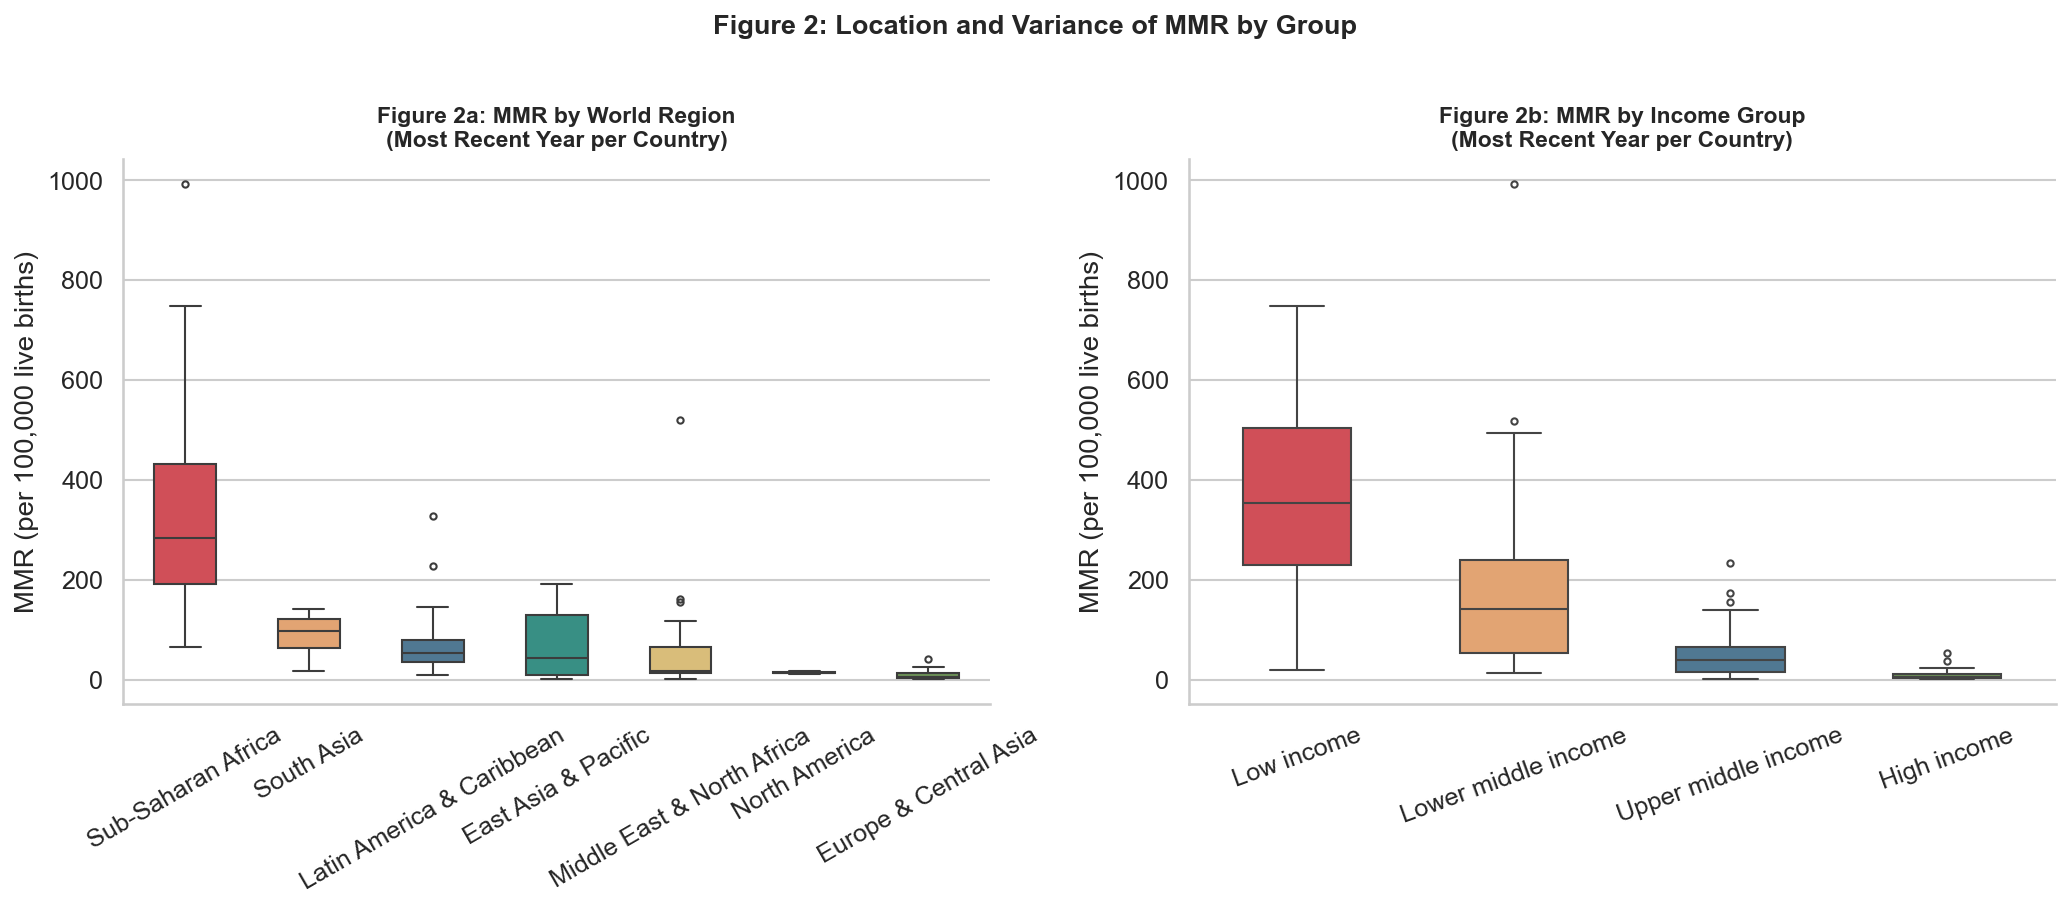

Figure 2 saved


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Figure 2a: by Region
lat_reg = latest.dropna(subset=["Region", "MMR"])
reg_order = (lat_reg.groupby("Region")["MMR"]
             .median().sort_values(ascending=False).index)
reg_colors = [REGION_COLORS.get(r, "grey") for r in reg_order]
sns.boxplot(data=lat_reg, x="Region", y="MMR", order=reg_order,
            palette=reg_colors, ax=axes[0], width=0.5, fliersize=3)
axes[0].set_title("Figure 2a: MMR by World Region\n(Most Recent Year per Country)",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("MMR (per 100,000 live births)")
axes[0].tick_params(axis="x", rotation=30)
 
# Figure 2b: by Income Group
lat_inc = latest.dropna(subset=["IncomeGroup", "MMR"])
inc_colors = [INCOME_COLORS[g] for g in INCOME_ORDER]
sns.boxplot(data=lat_inc, x="IncomeGroup", y="MMR", order=INCOME_ORDER,
            palette=inc_colors, ax=axes[1], width=0.5, fliersize=3)
axes[1].set_title("Figure 2b: MMR by Income Group\n(Most Recent Year per Country)",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("MMR (per 100,000 live births)")
axes[1].tick_params(axis="x", rotation=20)
 
plt.suptitle("Figure 2: Location and Variance of MMR by Group",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figure2_boxplots.png")
plt.show()
print("Figure 2 saved")

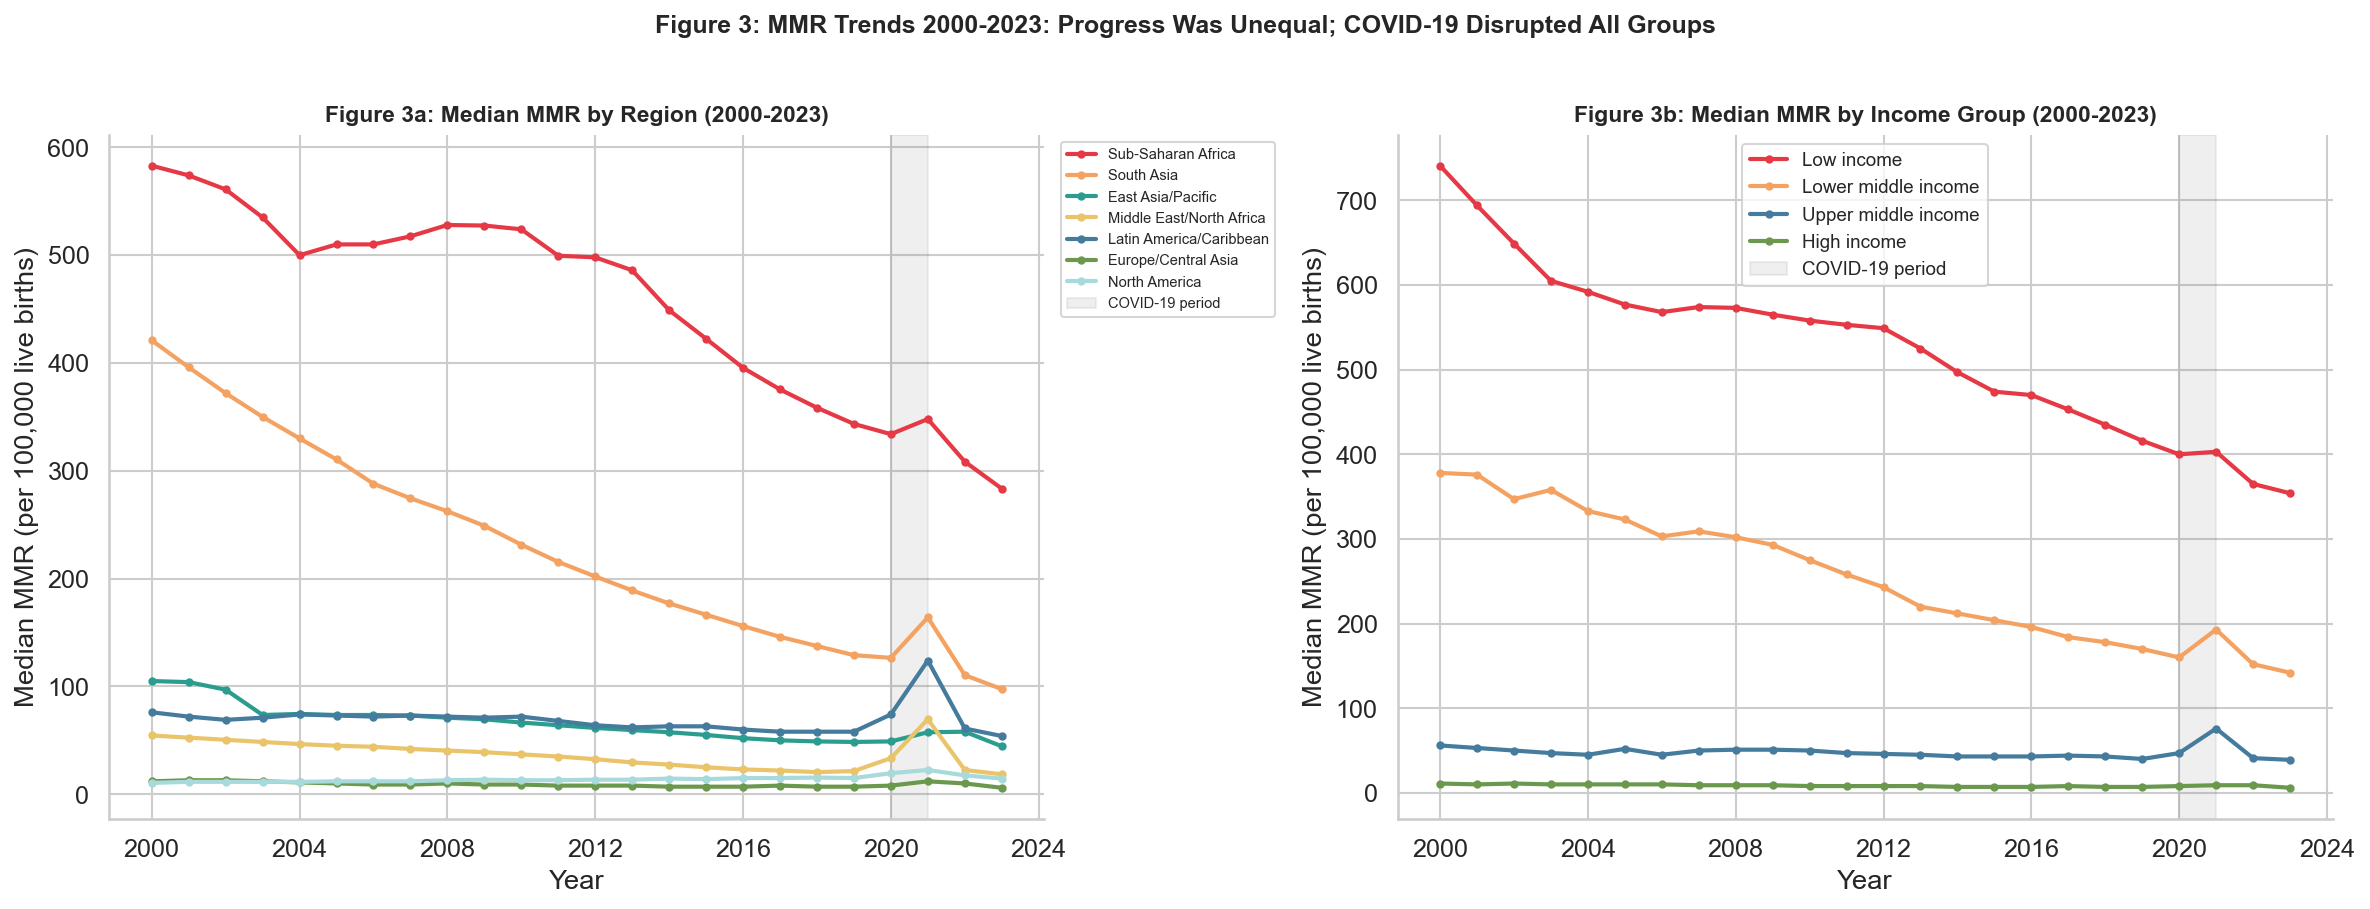

Figure 3 saved


In [11]:
# TIME DIMENSION — Trends + COVID Impact

 
# Figure 3a/3b: Trend lines 2000-2023
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# 3a: by Region
for region, color in REGION_COLORS.items():
    grp = df_clean[df_clean["Region"] == region].dropna(subset=["MMR"])
    if len(grp) == 0: continue
    trend = grp.groupby("Year")["MMR"].median().reset_index()
    axes[0].plot(trend["Year"], trend["MMR"], marker="o", markersize=3,
                 linewidth=2, label=region.replace(" & ", "/"), color=color)
 
axes[0].axvspan(2020, 2021, alpha=0.12, color="grey", label="COVID-19 period")
axes[0].set_title("Figure 3a: Median MMR by Region (2000-2023)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Median MMR (per 100,000 live births)")
axes[0].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(4))
 
# 3b: by Income Group
for group in INCOME_ORDER:
    grp = df_clean[df_clean["IncomeGroup"] == group].dropna(subset=["MMR"])
    trend = grp.groupby("Year")["MMR"].median().reset_index()
    axes[1].plot(trend["Year"], trend["MMR"], marker="o", markersize=3,
                 linewidth=2, label=group, color=INCOME_COLORS[group])
 
axes[1].axvspan(2020, 2021, alpha=0.12, color="grey", label="COVID-19 period")
axes[1].set_title("Figure 3b: Median MMR by Income Group (2000-2023)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Median MMR (per 100,000 live births)")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(4))
 
plt.suptitle("Figure 3: MMR Trends 2000-2023: Progress Was Unequal; COVID-19 Disrupted All Groups",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figure3_trends.png")
plt.show()
print("Figure 3 saved")
 

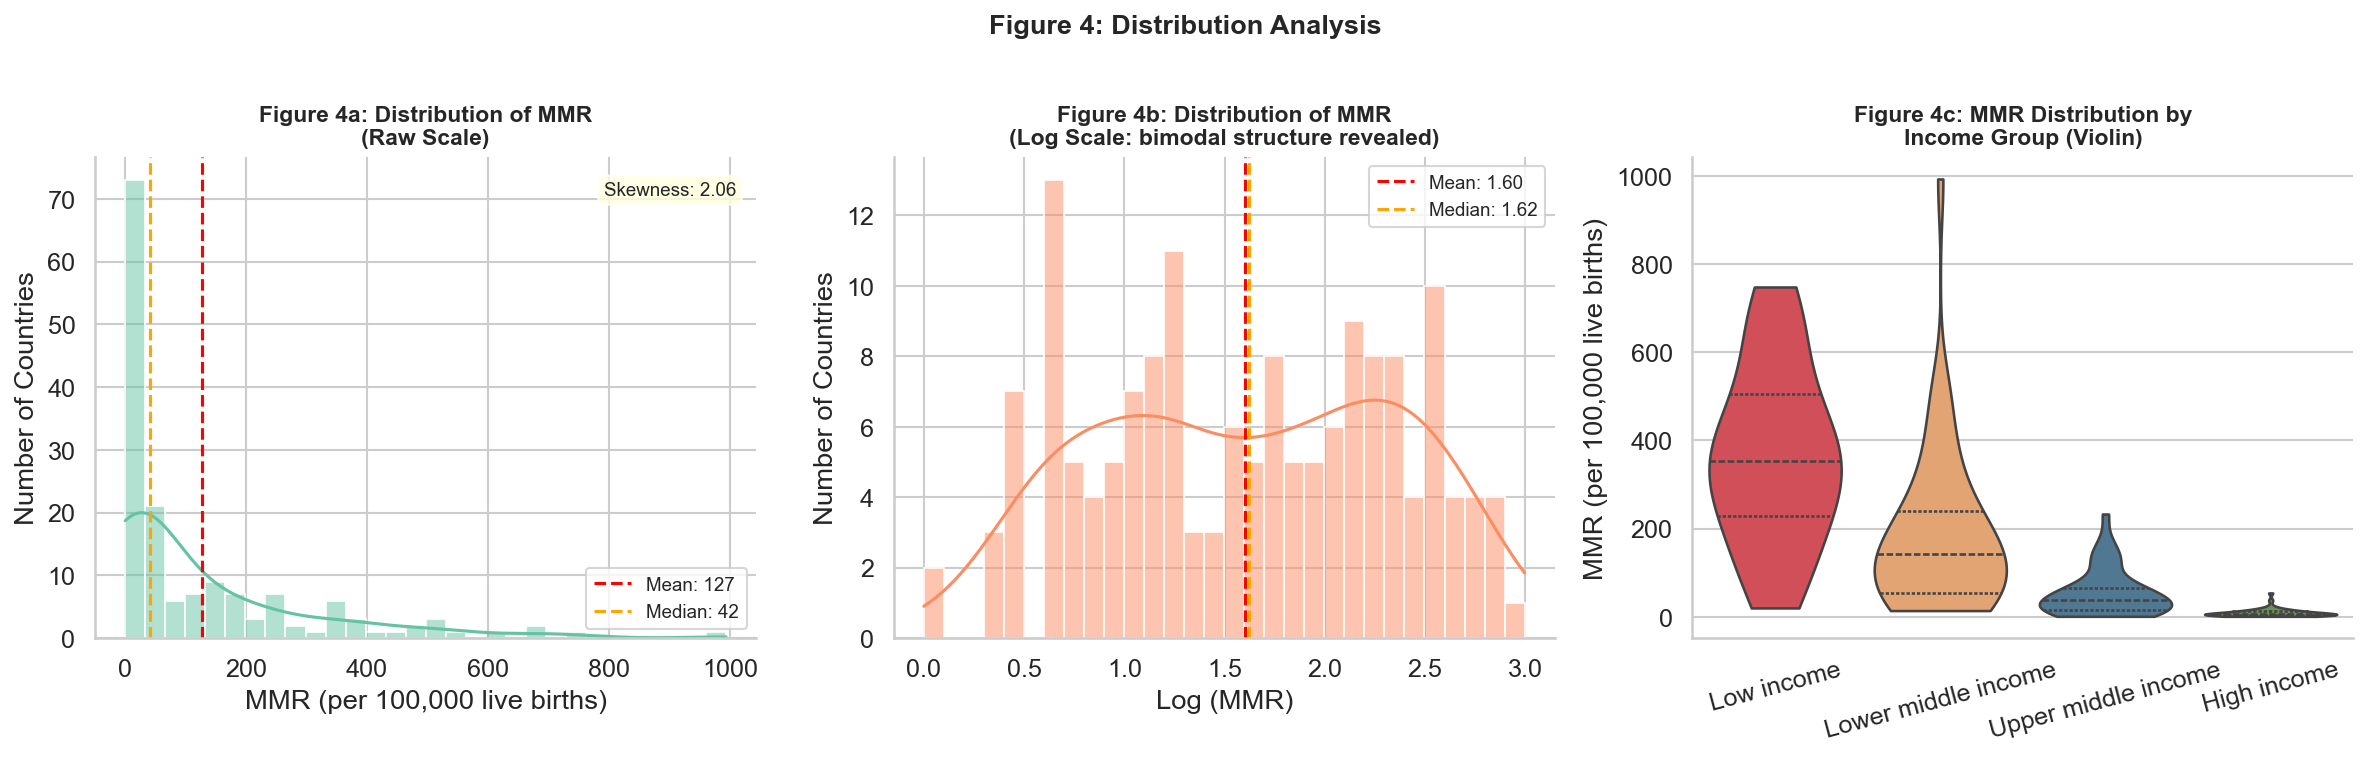

Figure 4 saved


In [12]:
# DISTRIBUTIONS
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
PALETTE = sns.color_palette("Set2")
 
# 4a: Histogram + KDE — raw MMR
data_raw = latest["MMR"].dropna()
sns.histplot(data_raw, bins=30, kde=True, color=PALETTE[0],
             ax=axes[0], edgecolor="white")
axes[0].axvline(data_raw.mean(),   color="red",    linestyle="--", lw=1.5,
                label=f"Mean: {data_raw.mean():.0f}")
axes[0].axvline(data_raw.median(), color="orange", linestyle="--", lw=1.5,
                label=f"Median: {data_raw.median():.0f}")
axes[0].set_title("Figure 4a: Distribution of MMR\n(Raw Scale)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("MMR (per 100,000 live births)")
axes[0].set_ylabel("Number of Countries")
axes[0].legend(fontsize=9)
skew = data_raw.skew()
axes[0].text(0.97, 0.95, f"Skewness: {skew:.2f}", transform=axes[0].transAxes,
             ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
 
# 4b: Histogram + KDE — log10 scale
data_log = np.log10(data_raw[data_raw > 0])
sns.histplot(data_log, bins=30, kde=True, color=PALETTE[1],
             ax=axes[1], edgecolor="white")
axes[1].axvline(data_log.mean(),   color="red",    linestyle="--", lw=1.5,
                label=f"Mean: {data_log.mean():.2f}")
axes[1].axvline(data_log.median(), color="orange", linestyle="--", lw=1.5,
                label=f"Median: {data_log.median():.2f}")
axes[1].set_title("Figure 4b: Distribution of MMR\n(Log Scale: bimodal structure revealed)",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Log (MMR)")
axes[1].set_ylabel("Number of Countries")
axes[1].legend(fontsize=9)
 
# 4c: Violin: by income group
viol_data = latest.dropna(subset=["IncomeGroup", "MMR"])
sns.violinplot(data=viol_data, x="IncomeGroup", y="MMR", order=INCOME_ORDER,
               palette=inc_colors, ax=axes[2], inner="quartile", cut = 0)
axes[2].set_title("Figure 4c: MMR Distribution by\nIncome Group (Violin)",
                  fontsize=11, fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("MMR (per 100,000 live births)")
axes[2].tick_params(axis="x", rotation=15)
 
plt.suptitle("Figure 4: Distribution Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figure4_distributions.png")
plt.show()
print("Figure 4 saved")

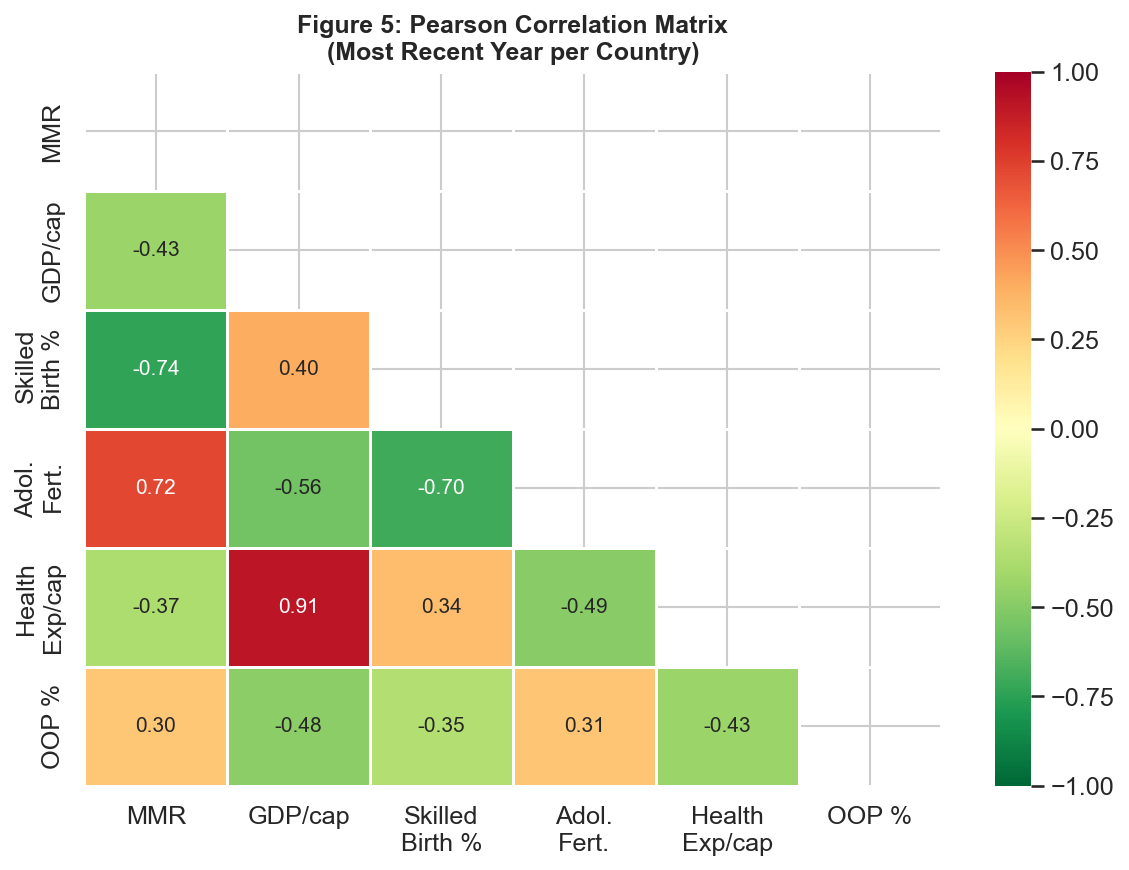

Figure 5 saved


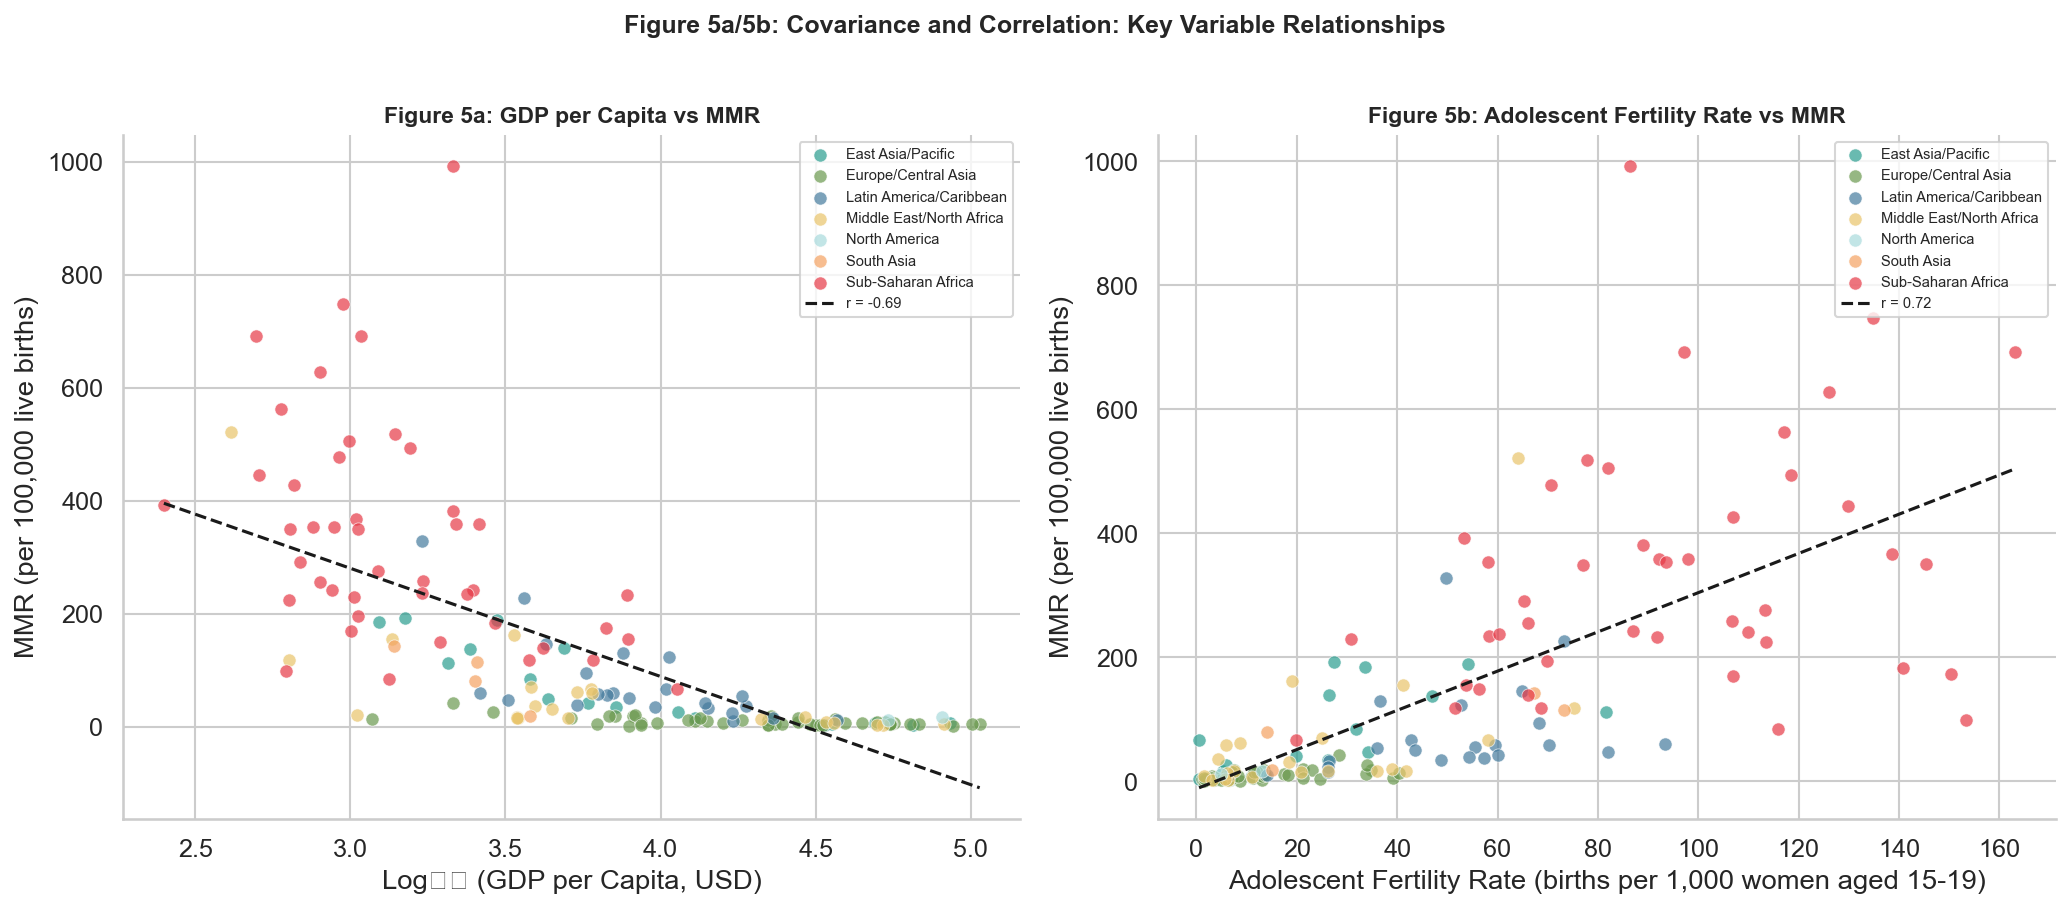

Figure 5a/5b saved  |  r(GDP)=-0.69  r(adol.fert.)=0.72


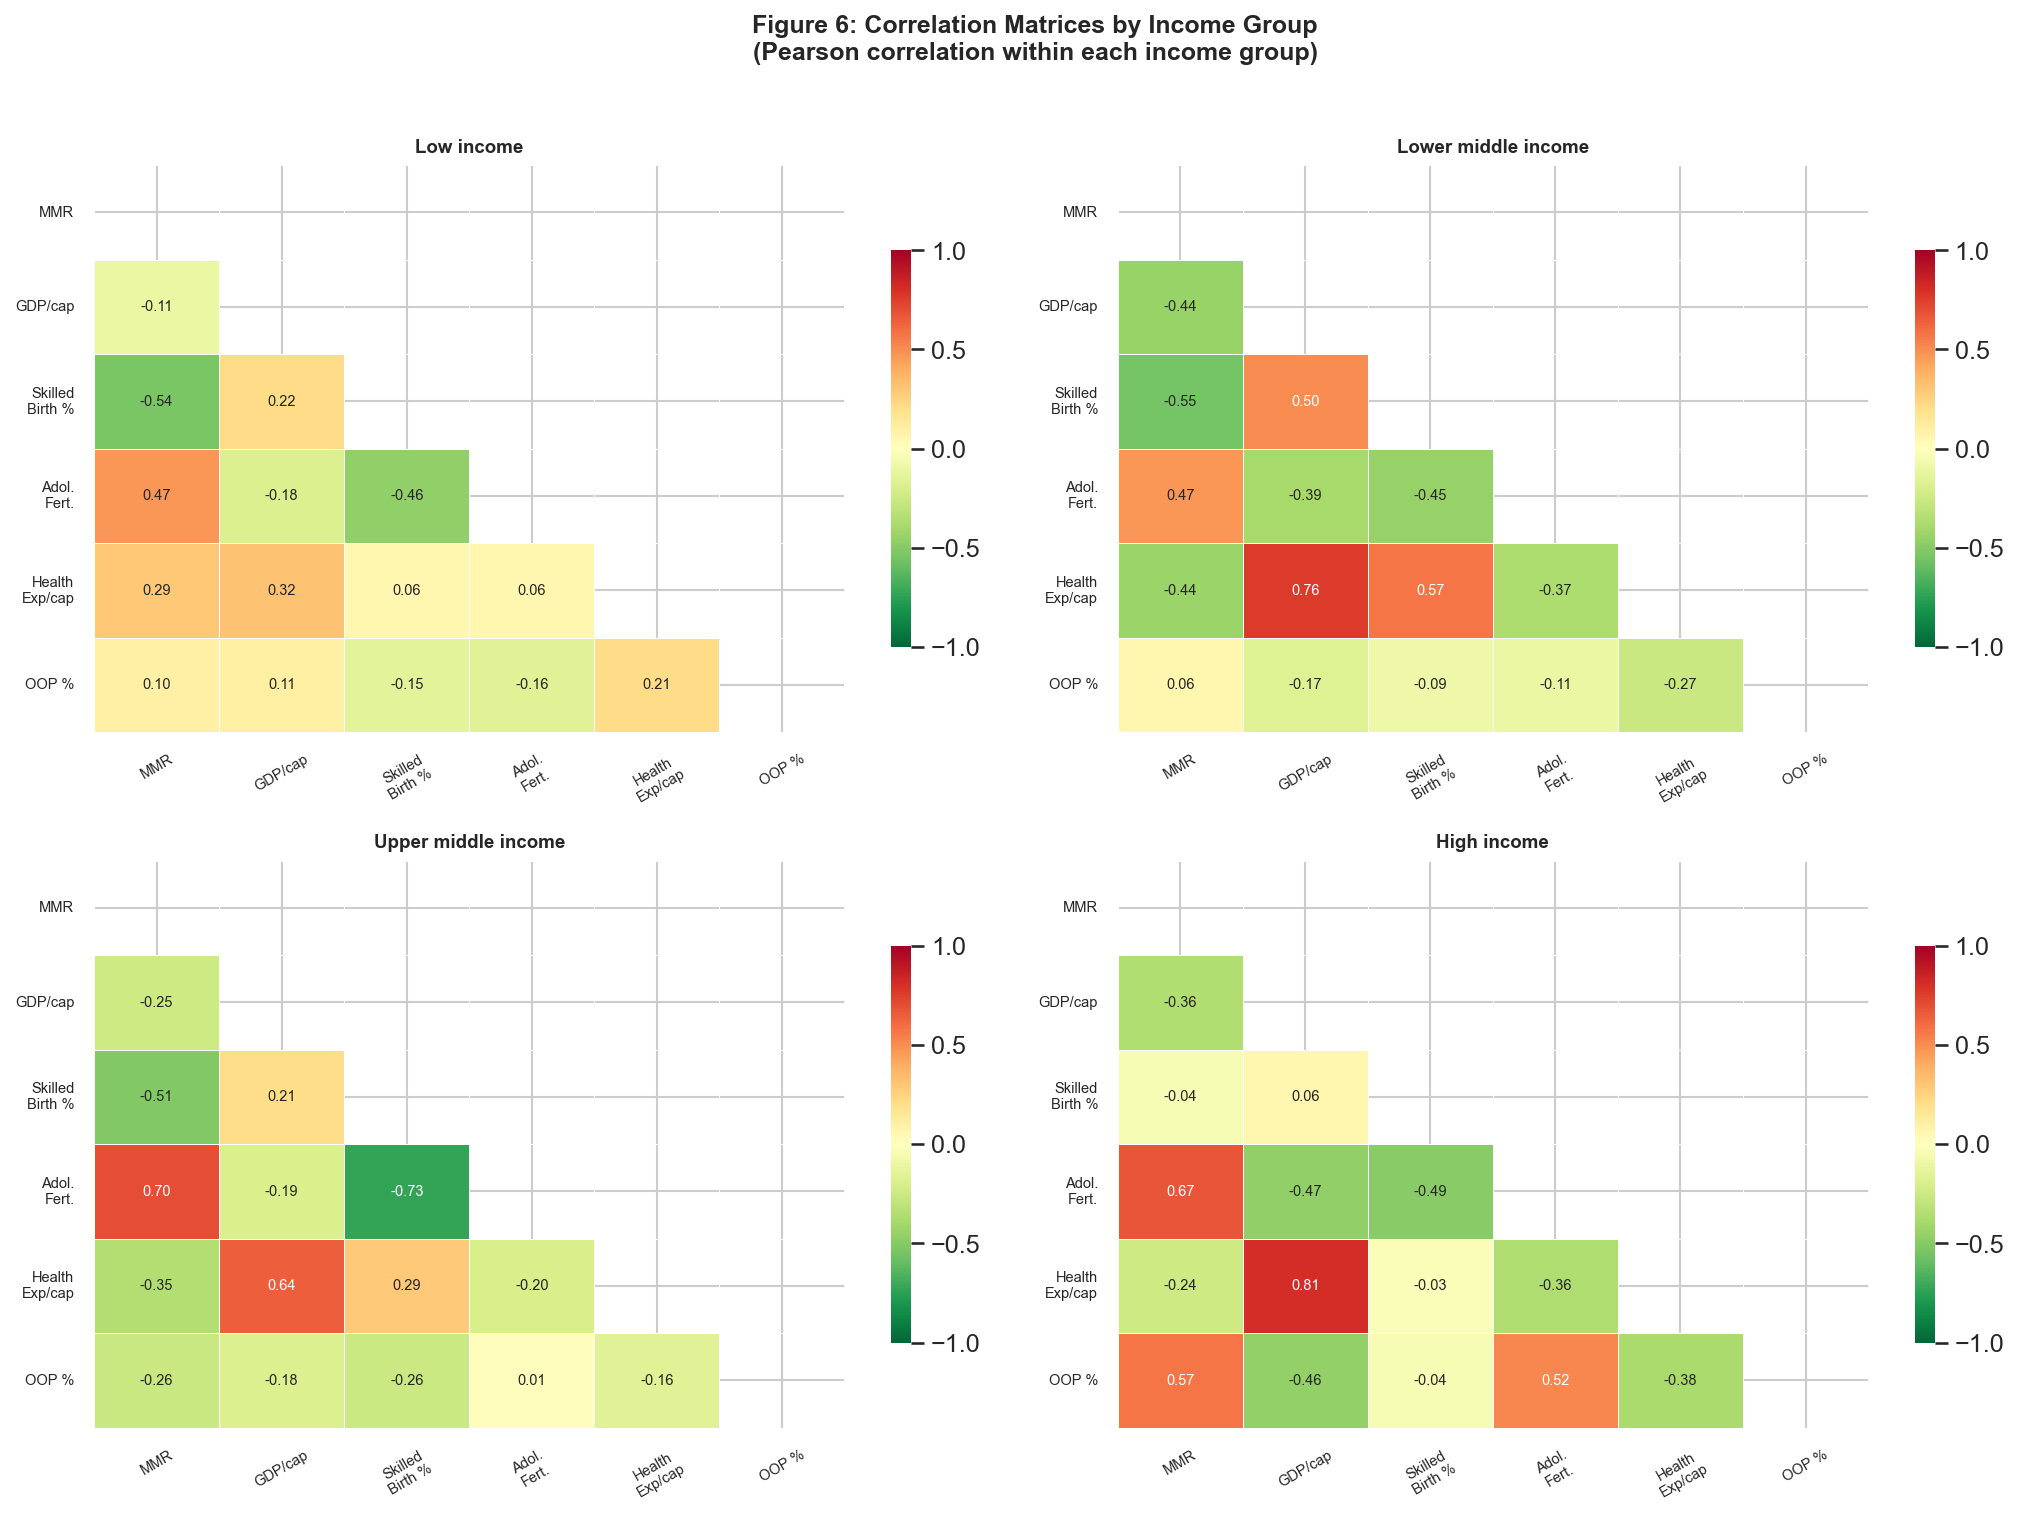

Figure 6 saved


In [13]:
# RELATIONSHIPS — Correlation, Scatter, Covariance

# Figure 5: Pearson Correlation Heatmap
corr_vars  = ["MMR", "GDP_per_capita", "Skilled_birth_pct",
               "Adolescent_fertility", "Health_exp_pc", "OOP_pct"]
corr_matrix = latest[corr_vars].corr(method="pearson").rename(
    index=VAR_LABELS, columns=VAR_LABELS)
 
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("Figure 5: Pearson Correlation Matrix\n(Most Recent Year per Country)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figure5_heatmap.png")
plt.show()
print("Figure 5 saved")
 
# Figures 5a & 5b: Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
def scatter_with_regression(ax, df_plot, xcol, ycol, title, xlabel, log_x=False):
    plot = df_plot.dropna(subset=[xcol, ycol, "Region"])
    if log_x:
        plot = plot[plot[xcol] > 0].copy()
        plot["x_val"] = np.log10(plot[xcol])
    else:
        plot["x_val"] = plot[xcol]
 
    for region, grp in plot.groupby("Region"):
        axes[ax].scatter(grp["x_val"], grp[ycol], label=region.replace(" & ", "/"),
                         color=REGION_COLORS.get(region, "grey"),
                         s=40, alpha=0.7, edgecolors="white", lw=0.4)
 
    x_, y_ = plot["x_val"], plot[ycol]
    m, b, r, p, _ = stats.linregress(x_, y_)
    xl = np.linspace(x_.min(), x_.max(), 100)
    axes[ax].plot(xl, m * xl + b, "k--", lw=1.5, label=f"r = {r:.2f}")
    axes[ax].set_title(title, fontsize=11, fontweight="bold")
    axes[ax].set_xlabel(xlabel)
    axes[ax].set_ylabel("MMR (per 100,000 live births)")
    axes[ax].legend(fontsize=7, ncol=1)
    return r, p
 
r1, p1 = scatter_with_regression(
    0, latest, "GDP_per_capita", "MMR",
    "Figure 5a: GDP per Capita vs MMR",
    "Log\u2081\u2080 (GDP per Capita, USD)", log_x=True)
r2, p2 = scatter_with_regression(
    1, latest, "Adolescent_fertility", "MMR",
    "Figure 5b: Adolescent Fertility Rate vs MMR",
    "Adolescent Fertility Rate (births per 1,000 women aged 15-19)")
 
plt.suptitle("Figure 5a/5b: Covariance and Correlation: Key Variable Relationships",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figure5ab_scatter.png")
plt.show()
print(f"Figure 5a/5b saved  |  r(GDP)={r1:.2f}  r(adol.fert.)={r2:.2f}")
 
# Figures 6 Correlation matrices per group
def draw_corr(data, title, ax):
    sub = data[corr_vars].dropna(how="all")

    if len(sub) < 4:
        ax.text(0.5, 0.5, f"n={len(sub)} — insufficient",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title, fontsize=9)
        return
    corr = sub.corr(method="pearson").rename(index=VAR_LABELS, columns=VAR_LABELS)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0,
        vmin=-1, vmax=1, linewidths=0.4, ax=ax, annot_kws={"size": 7}, cbar_kws={"shrink": 0.7})
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)
 
# by income group
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, group in zip(axes.flatten(), INCOME_ORDER):
    draw_corr(latest[latest["IncomeGroup"] == group], group, ax)

plt.suptitle("Figure 6: Correlation Matrices by Income Group\n"
             "(Pearson correlation within each income group)",
             fontsize=12, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("figure6_corr_income.png")
plt.show()
print("Figure 6 saved")

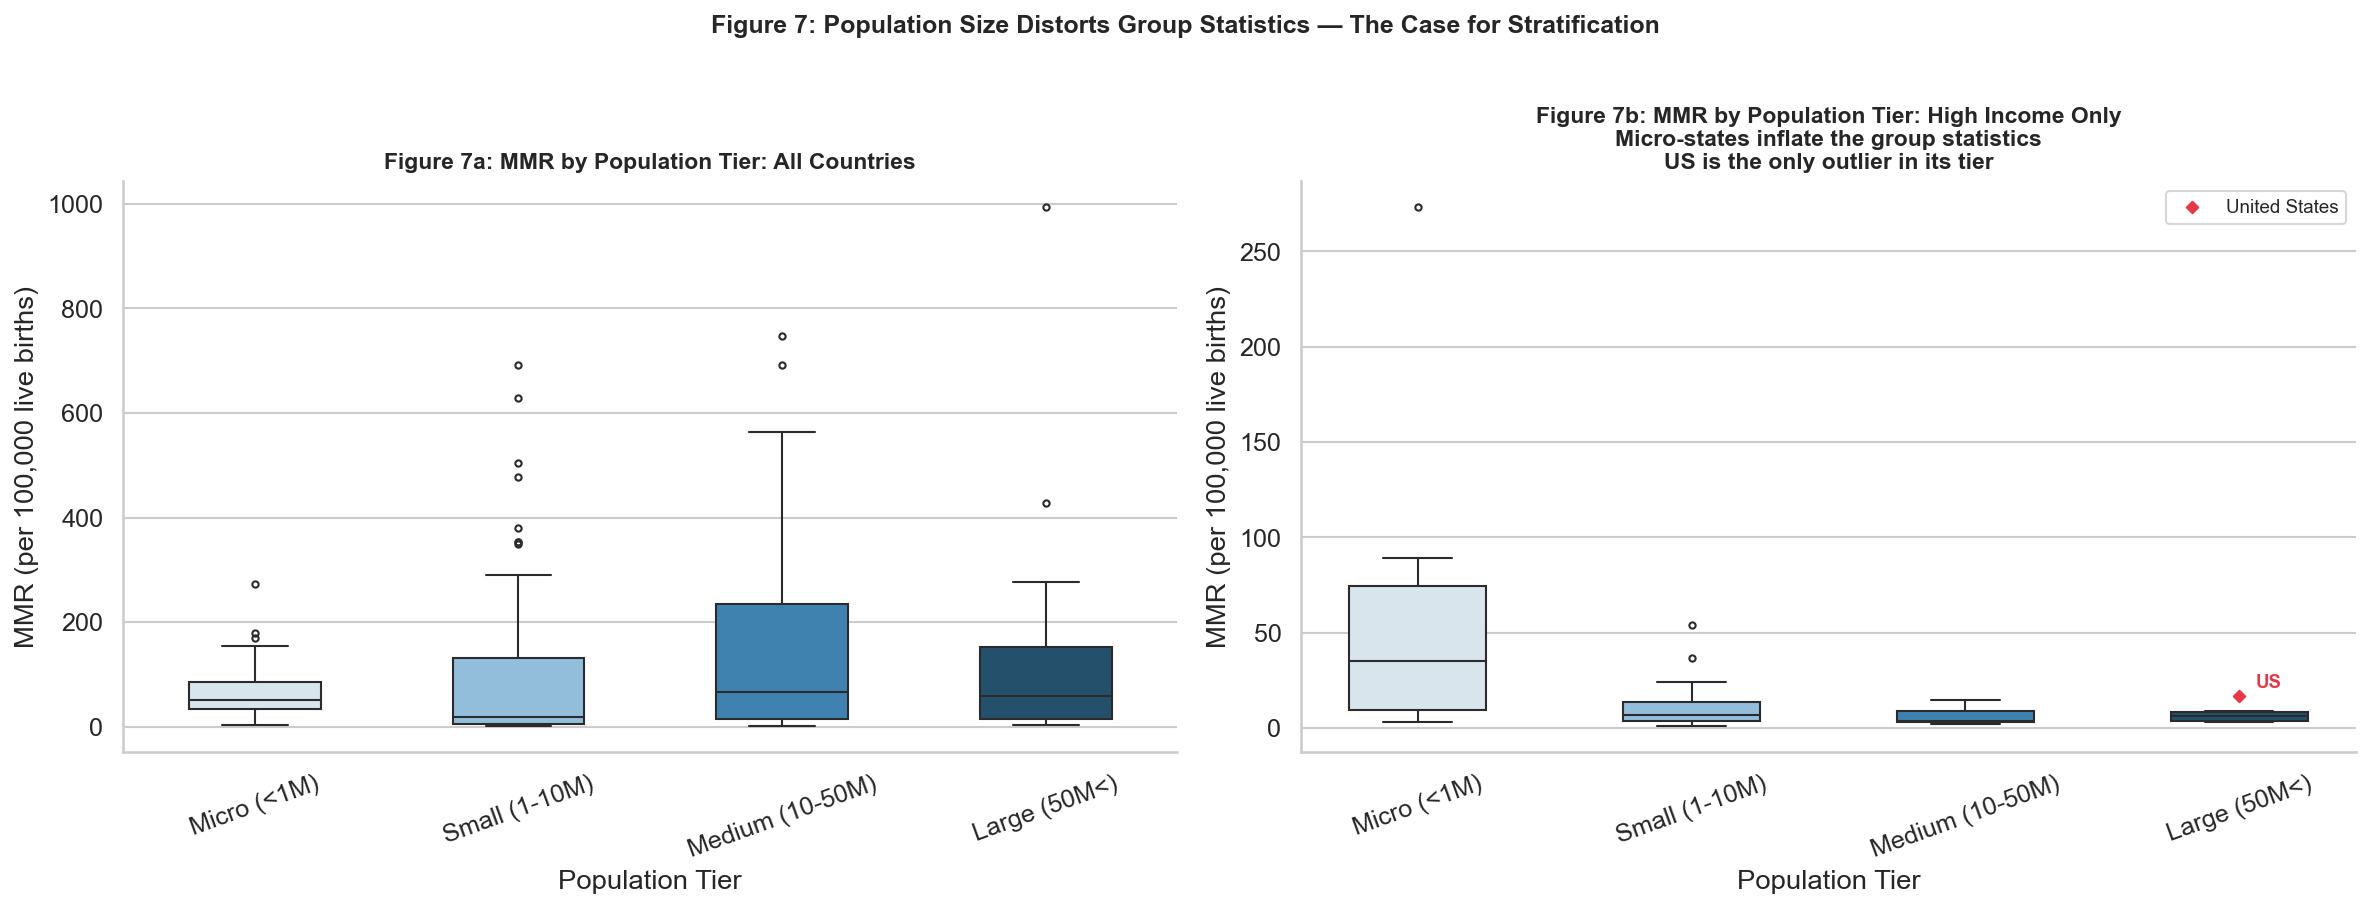

Figure 7 saved


In [14]:
# POPULATION STRATIFICATION

# Figure 7
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
tier_order   = POP_LABELS
tier_palette = ["#d4e6f1", "#85c1e9", "#2e86c1", "#1a5276", "#e63946"]
 
# 7a: all countries, all tiers
tier_all = latest_full.dropna(subset=["Pop_tier", "MMR"])
sns.boxplot(data=tier_all, x="Pop_tier", y="MMR", order=tier_order,
            palette=tier_palette, ax=axes[0], width=0.5, fliersize=3)
axes[0].set_title("Figure 7a: MMR by Population Tier: All Countries",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Population Tier")
axes[0].set_ylabel("MMR (per 100,000 live births)")
axes[0].tick_params(axis="x", rotation=20)
 
# 7b: High income only
hi_full = latest_full[latest_full["IncomeGroup"] == "High income"].dropna(subset=["Pop_tier","MMR"])
sns.boxplot(data=hi_full, x="Pop_tier", y="MMR", order=tier_order,
            palette=tier_palette, ax=axes[1], width=0.5, fliersize=3)
usa_hi = hi_full[hi_full["Country Name"] == "United States"]
if not usa_hi.empty:
    tier_idx = tier_order.index(str(usa_hi["Pop_tier"].values[0]))
    axes[1].scatter([tier_idx], [usa_hi["MMR"].values[0]],
                    color=USA_COLOR, s=15, zorder=5, marker="D",
                    label="United States")
    axes[1].annotate("US", (tier_idx, usa_hi["MMR"].values[0]),
                     textcoords="offset points", xytext=(8, 4),
                     fontsize=9, color=USA_COLOR, fontweight="bold")
    axes[1].legend(fontsize=9)

 
axes[1].set_title("Figure 7b: MMR by Population Tier: High Income Only\n"
                  "Micro-states inflate the group statistics\n"
                  "US is the only outlier in its tier",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Population Tier")
axes[1].set_ylabel("MMR (per 100,000 live births)")
axes[1].tick_params(axis="x", rotation=20)
 
plt.suptitle("Figure 7: Population Size Distorts Group Statistics — The Case for Stratification",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figure7_pop_tiers.png")
plt.show()
print("Figure 7 saved")
